![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [49]:
import warnings
warnings.filterwarnings('ignore')

In [50]:
# Importación de librerías
%matplotlib inline
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from matplotlib import pyplot as plt

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [51]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [52]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [53]:
# Celda 1
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')

# Parámetros del árbol de decisión
max_depth = None # nivel de profundidad del árbol
num_pct = 10 # numero de percentiles para dividir las variables
max_features = None # Usa todas las variables disponibles
min_gain = 0.001 # Solo se hace un split si la ganancia de información es mayor a este valor

In [54]:
# Función para calcular el MSE de un nodo
def mse_nodo(y1):
    if len(y1) == 0:
        return 0
    return ((y1 - y1.mean()) ** 2).mean()

# Función para calcular el RMSE
def rmse_nodo(y1):
    if len(y1) == 0:
        return 0
    return np.sqrt(((y1 - y1.mean()) ** 2).mean())

In [55]:
# Función para encontrar el mejor split de los features basado en la ganancia de información (Menor MSE)

def best_split(X, y, num_pct = 10):

    nro_features = range(X.shape[1]) # Número de features disponibles

    best_split = [0, 0, 0]  # j, split, gain

    for j in nro_features: # j es el índice de la variable a evaluar

        valores_unicos = np.unique(X.iloc[:, j]) # Valores únicos de la variable j

        if len(valores_unicos) <= num_pct: # Si la variable contiene menos valores únicos que el número de percentiles, por eficiencia se evalúan solo los valores únicos de la variable
            splits = valores_unicos[:-1] # Evaluar todos los valores únicos excepto el último
        else:
            splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100 / (num_pct)).tolist()) # División de la variable en percentiles
            splits = np.unique(splits) # Eliminar valores duplicados
        
        for split in splits:

            filter_l = X.iloc[:,j] < split # Filtro para el nodo izquierdo (Todos los valores de la variable j menores al valor del split)
            y_l = y.loc[filter_l] # Variable respuesta para el nodo izquierdo (Filtro aplicado a la variable respuesta para el nodo izquierdo)
            y_r = y.loc[~filter_l] # Variable respuesta para el nodo derecho (Filtro aplicado a la variable respuesta para el nodo derecho)

            mse_l = mse_nodo(y_l) # MSE del nodo izquierdo
            mse_r = mse_nodo(y_r) # MSE del nodo derecho

            gain = mse_nodo(y) - (len(y_l) * mse_l + len(y_r) * mse_r) / len(y) # Ganancia de información
            if gain > best_split[2]: # Selecciona la mejor ganancia de información en cada iteración
                best_split = [j, split, gain] # Actualiza el mejor split encontrado

    return best_split

j, split, gain = best_split(X, y)
j, split, gain

(0, 2013.0, 8789494.426667094)

In [56]:
def tree_grow(X, y, level = 0, min_gain = 0.001, num_pct = 10, max_depth = None):

    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred = y.iloc[:1].values[0], y_prob = 0.5, level = level, split = -1, n_samples = 1, gain = 0) # split = - 1 define que no hay división, y_prob = 0.5 es la probabilidad de predicción para el nodo hoja
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean() # Calcula la predicción del nodo como 1 si la media de y es mayor o igual a 0.5, y 0 en caso contrario 
    
    tree = dict(y_pred = y_pred, level = level, split = -1, n_samples = X.shape[0], gain = gain) # Guarda el arbol con la predicción, la probabilidad correspondiente, el nivel del nodo, la división realizada, el número de muestras en el nodo y la ganancia de información obtenida con la división
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

In [57]:
# Aplicación de la función tree_grow
tree = tree_grow(X, y, level=0, min_gain=0.001, max_depth=4, num_pct=10)
tree

{'y_pred': 14538.403716055265,
 'level': 0,
 'split': [0, 2013.0],
 'n_samples': 10495,
 'gain': 8789494.426667094,
 'sl': {'y_pred': 9756.504461221688,
  'level': 1,
  'split': [0, 2011.0],
  'n_samples': 2914,
  'gain': 2852525.302292848,
  'sl': {'y_pred': 8232.290784557908,
   'level': 2,
   'split': [1, 97662.0],
   'n_samples': 1606,
   'gain': 852556.6508446848,
   'sl': {'y_pred': 9363.733644859813,
    'level': 3,
    'split': [0, 2008.0],
    'n_samples': 642,
    'gain': 689117.7883440317,
    'sl': {'y_pred': 8422.825622775801,
     'level': 4,
     'split': -1,
     'n_samples': 281,
     'gain': 379237.7295681741},
    'sr': {'y_pred': 10096.130193905818,
     'level': 4,
     'split': -1,
     'n_samples': 361,
     'gain': 401557.3720880747}},
   'sr': {'y_pred': 7478.778008298756,
    'level': 3,
    'split': [0, 2008.0],
    'n_samples': 964,
    'gain': 313591.5181018696,
    'sl': {'y_pred': 6962.403071017275,
     'level': 4,
     'split': -1,
     'n_samples': 521

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def tree_predict_single(tree, x):
    # Si es nodo hoja (sin split)
    if tree['split'] == -1:
        return tree['y_pred']
    
    j, split = tree['split']
    
    # Ir a la rama izquierda o derecha
    if x.iloc[j] < split:
        return tree_predict_single(tree['sl'], x)
    else:
        return tree_predict_single(tree['sr'], x)


def tree_predict(tree, X):
    return np.array([tree_predict_single(tree, X.iloc[i]) for i in range(len(X))])

from sklearn.metrics import mean_squared_error, r2_score

pred_manual = tree_predict(tree, X_test)

rmse_manual = np.sqrt(mean_squared_error(y_test, pred_manual))
mae_manual = mean_absolute_error(y_test, pred_manual)
r2_manual = r2_score(y_test, pred_manual)

print(rmse_manual)
print(mae_manual)
print(r2_manual)


1814.145331713227
1357.348894304284
0.7848397020905045


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [59]:
# Celda 2

# Generar las muestras Boostrap para cada árbol del Bagging Manual
n_estimators = 10
np.random.seed(123)

n_samples = X_train.shape[0]
samples = [np.random.choice(a = n_samples, size = n_samples, replace = True) for _ in range(n_estimators)]

# Entrenar un árbol de decisión para cada muestra Boostrap

predicciones = np.zeros((X_test.shape[0], n_estimators)) # X_test.shape[0] representa el nro de observaciones (filas) y n_estimators (columnas) cada uno de los modelos estimados.
modelos_entrenados = []

for i, sample in enumerate(samples):
    X_boot = X_train.iloc[sample].reset_index(drop=True)
    y_boot = y_train.iloc[sample].reset_index(drop=True)

    tree = tree_grow(X_boot, y_boot, level=0, min_gain=0.001, max_depth=4, num_pct=10)
    modelos_entrenados.append(tree)
    predicciones[:, i] = tree_predict(tree, X_test)

# Promedio de las predicciones de los árboles para cada observación del set de test
pred_bagging_manual = predicciones.mean(axis = 1)
rmse_bagging_manual = np.sqrt(mean_squared_error(y_test, pred_bagging_manual))
mae_bagging_manual = mean_absolute_error(y_test, pred_bagging_manual)
r2_bagging_manual = r2_score(y_test, pred_bagging_manual)

print(rmse_bagging_manual)
print(mae_bagging_manual)
print(r2_bagging_manual)

1731.0545675218711
1282.8333244452876
0.8040977147248312


### **Hallazgos:**

- El bagging manual superó al árbol de decisión individual con mejoras en las 3 métricas evaluadas.
    - Mejora del R2 score del 0.785 a 0.804 que es un 2.5% más que el árbol de decisión único.
    - Reducción del RMSE y el MAE
- Cada árbol fue entrenado con una muestra bootstrap distinta, lo que introduce variabilidad entre estimadores y permite que el promedio final cancele los errores individuales de cada modelo.
- El bagging reduce la varianza sin aumentar el sesgo de forma significativa, lo que explica la mejora al evaluar en test sin necesidad de cambiar la profundidad de los estimadores base (árbol de decisión manual).
- El ensamblaje por bagging reduce de forma efectiva la varianza, lo que implica una mejora de la capacidad de generalización del modelo y aumenta su capacidad predictora.
- La limitación actual de este modelo manual es la cantidad de estimadores y la profundidad. Es posible que con un mayor número de estimadores (árboles) o una profundidad mayor, el modelo tenga la capacidad de reconocer relaciones de mayor complejidad, aumentando su desempeño.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [60]:
# Celda 3

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

n_features = X_train.shape[1]

modelo_DTR = DecisionTreeRegressor(max_features = int(np.log(n_features)))
bagg_DTR = BaggingRegressor(estimator = modelo_DTR, n_estimators = 10, bootstrap= True, random_state = 42)

bagg_DTR.fit(X_train, y_train)


BaggingRegressor(estimator=DecisionTreeRegressor(max_features=2),
                 random_state=42)

In [61]:
pred_bagg_DTR = bagg_DTR.predict(X_test)

rmse_bagg_DTR = np.sqrt(mean_squared_error(y_test, pred_bagg_DTR))
mae_bagg_DTR = mean_absolute_error(y_test, pred_bagg_DTR)
r2_bagg_DTR = r2_score(y_test, pred_bagg_DTR)

print(rmse_bagg_DTR)
print(mae_bagg_DTR)
print(r2_bagg_DTR)

1813.0409476471518
1353.424136561091
0.7851015854948061


### **Hallazgos:**

- El modelo usando la librería SKLearn tomó 10 árboles de decisión como estimadores base, este modelo fue evaluado con las siguientes métricas:
    - R2: 0.785 Lo que quiere decir que el modelo Bagging de SKLearn explica el 78.5% de la varianza del precio de los automóviles.
    - RMSE de 1813 que es el error promedio de predicción.
    - MAE de 1353 indica que hay valores atípicos que están generando ruido y que provocan un incremento en el RMSE.
- El uso del parámetro `max_features = int(np.log(n_features))` hace que el modelo esté sujeto a una restricción en el número de variables evaluadas en cada split. Existe mayor diversidad en los estimadores pero restringe el poder predictivo por árbol.
- Haciendo la comparativa con el Bagging modelado de forma manual, el cual  no está sujeto a restricción de variables, evidencia el hecho que `max_features` es el factor que determina la diferencia de desempeño entre los 2 modelos.
- Con el objetivo de mejorar el desempeño del modelo, se sugiere aumentar el número de estimadores o ser más flexibles con el uso de `max_features`.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [62]:
# Celda 4

# Definición de modelo Random Forest para un problema de clasificación
rfr = RandomForestRegressor()
rfr

RandomForestRegressor()

In [63]:
#Impresión de desempeño del modelo usando la función cross_val_score
pd.Series(cross_val_score(rfr, X, y, cv=10)).describe()

count    10.000000
mean      0.801057
std       0.011173
min       0.781445
25%       0.795800
50%       0.802171
75%       0.805759
max       0.816428
dtype: float64

In [64]:
# RMSE obtenido con el modelo por medio de cross-validation
print(f'RMSE promedio del modelo con 10-fold cross-validation: {-cross_val_score(rfr, X, y, cv=10, scoring="neg_root_mean_squared_error").mean()}')
# MAE obtenido con el modelo por medio de cross-validation
print(f'MAE promedio del modelo con 10-fold cross-validation: {-cross_val_score(rfr, X, y, cv=10, scoring="neg_mean_absolute_error").mean()}')
# R2 obtenido con el modelo por medio de cross-validation
print(f'R2 promedio del modelo con 10-fold cross-validation: {cross_val_score(rfr, X, y, cv=10, scoring="r2").mean()}')

RMSE promedio del modelo con 10-fold cross-validation: 1746.964465020798
MAE promedio del modelo con 10-fold cross-validation: 1305.254566253518
R2 promedio del modelo con 10-fold cross-validation: 0.801468343089093


#### Procedimiento y conclusiones
Se entrena el modelo de Random Forest con los parámetros por defecto, y se realiza el cálculo del mejor RMSE por medio del método de validación cruzada con 10 muestras. Se observa que el mejor desempeño comprende un RMSE promedio de 1747, un MAE de 1304 y R2 de 80. Se sepera mejorar este resultado base con la calibración de 3 hiperparámetros del modelo.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [65]:
# Celda 5

# Creación de lista de valores para iterar sobre diferentes valores de n_estimators
estimator_range = range(10, 410, 10)

# Definición de lista para almacenar los errores cuadráticos medios para cada valor de n_estimators
rmse_scores_ne = []

# Uso de un 10-fold cross-validation para cada valor de n_estimators
for estimator in estimator_range:
    rfr2 = RandomForestRegressor(n_estimators=estimator, random_state=1, n_jobs=-1)
    rmse_scores_ne.append(-cross_val_score(rfr2, X, y, cv=5, scoring='neg_root_mean_squared_error').mean())

Text(0, 0.5, 'RMSE')

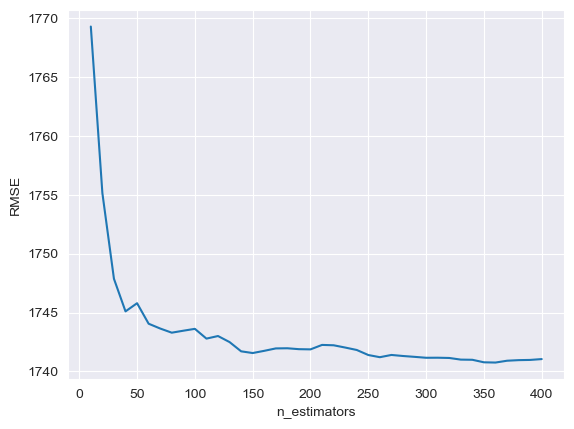

In [66]:
# Gráfica del desempeño del modelo vs la cantidad de n_estimators

plt.plot(estimator_range, rmse_scores_ne)
plt.xlabel('n_estimators')
plt.ylabel('RMSE')

In [67]:
# Creación de lista de valores para iterar sobre diferentes valores de max_features
feature_range = range(1, len(X.columns)+1)

# Definición de lista para almacenar el mse para cada valor de max_features
rmse_scores_mf = []

# Uso de un 5-fold cross-validation para cada valor de max_features
for feature in feature_range:
    clf = RandomForestRegressor(n_estimators=300, max_features=feature, random_state=1, n_jobs=-1)
    rmse_scores_mf.append(-cross_val_score(clf, X, y, cv=5, scoring='neg_root_mean_squared_error').mean())

Text(0, 0.5, 'RMSE')

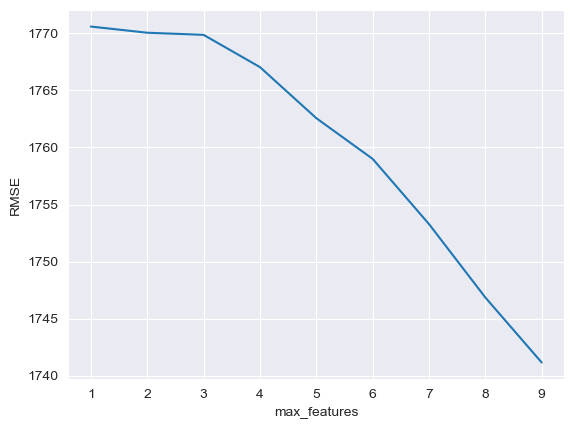

In [68]:
# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.plot(feature_range, rmse_scores_mf)
plt.xlabel('max_features')
plt.ylabel('RMSE')

In [69]:
# Pte calibrar max_depth y entrenar el modelo con los mejores hiperparámetros encontrados

# Caliración de max_depth
depth_range = range(1, 20)
rmse_scores_md = []
for depth in depth_range:
    clf = RandomForestRegressor(n_estimators=300, max_features=5, max_depth=depth, random_state=1, n_jobs=-1)
    rmse_scores_md.append(-cross_val_score(clf, X, y, cv=5, scoring='neg_root_mean_squared_error').mean())

Text(0, 0.5, 'RMSE')

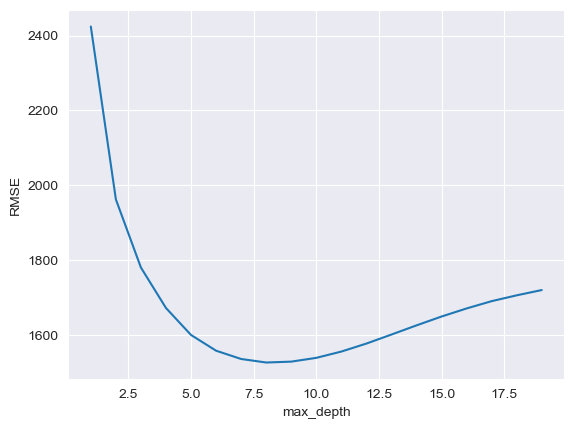

In [70]:
# Gráfica del desempeño del modelo vs la profundidad máxima de los árboles

plt.plot(depth_range, rmse_scores_md)
plt.xlabel('max_depth')
plt.ylabel('RMSE')

In [71]:
# Resumen de los mejores hiperparámetros encontrados y su desempeño en RMSE
print(f'Mejor n_estimators: {estimator_range[rmse_scores_ne.index(min(rmse_scores_ne))]}, RMSE: {min(rmse_scores_ne)}')
print(f'Mejor max_features: {feature_range[rmse_scores_mf.index(min(rmse_scores_mf))]}, RMSE: {min(rmse_scores_mf)}')
print(f'Mejor max_depth: {depth_range[rmse_scores_md.index(min(rmse_scores_md))]}, RMSE: {min(rmse_scores_md)}')

Mejor n_estimators: 360, RMSE: 1740.745940328418
Mejor max_features: 9, RMSE: 1741.1515359187658
Mejor max_depth: 8, RMSE: 1526.7634551516353


In [72]:
# entrenar modelo con mejores hiperparámetros encontrados
mejor_rf = RandomForestRegressor(n_estimators=360, max_features=9, max_depth=8, random_state=1, n_jobs=-1)
mejor_rf.fit(X_train, y_train)
# evaluación del modelo con el conjunto de prueba
y_pred = mejor_rf.predict(X_test)
# cross validation con 5 muestras para evaluar el desempeño del modelo con los mejores hiperparámetros encontrados
rmse_final_rf = -cross_val_score(mejor_rf, X, y, cv=5, scoring='neg_root_mean_squared_error').mean()
print(f'RMSE final del modelo con los mejores hiperparámetros: {rmse_final_rf}')

RMSE final del modelo con los mejores hiperparámetros: 1535.3206872217065


#### Procedimiento y Conclusiones
A partir del desempeño encontrado en el modelo de Random Forest sin parámetros calibrados, se realizó la calibración para 3 hiperparámetros. Se usó validación cruzada con 5 muestras para tener un buen desempeño y también no tener largos tiempos de procesamiento. El primer hiperparámetro, 'n_estimators' se utilizó un rango entre 10 a 410 estimadores para evaluar su desempeño, se encuentra que el mejor desempeño se encuentra con 360 estimadores. Igualmente, para las max_features se encontró que su mejor desempeño se hace con todas las variables predictoras. Finalmente, con el max_depth se encuentra que la profundidad máxima es hasta 8 niveles de ramificación. Los otros 2 estimadores muestran una mejora pequeña frente al modelo inicial. Sin embargo, al comparar el desempeño final con los demás resultados, se observa que el mejor desempeño se encuentra en el modelo con 300 estimadores y max features de 5, lo que sugiere que la combinación de los mejores estimadores por separado no muestra su mejor desempeño. Finalmente, comparando con el modelo sin calibrar, la diferencia se observa principalmente en el max_depth, considerando que arroja un RMSE menor de 1526 con parámetros fijos de 300 estimadores, 5 variables y profundidad de 8.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [73]:
# Celda 6
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [74]:
# Celda 6
# Importación y definición de modelo XGBRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
xgbr = XGBRegressor()
xgbr

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [75]:
# Entrenamiento y desempeño del modelo XGBRegressor
xgbr.fit(X_train, y_train)
y_pred = xgbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

RMSE: 1605.2355199928948
MAE: 1185.2272991506386
R2: 0.8315404997841507


### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [76]:
# Celda 7
from sklearn.model_selection import RandomizedSearchCV
# Creamos un diccionario con el universo de parámetros
param_dist = {
    'n_estimators': [100, 500, 1000],          
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Define qué tan rápido aprende el modelo, un número muy alto convergerá a una solución muy pronto, uno muy pequeño es más flexible pero puede ser más demorado
    'gamma': [0, 0.1, 0.5, 1, 5], # Hace referencia a la ganancia mínima para que el modelo tenga permitido hacer un split, a mayor gamma más simple el modelo           
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9], # Es el porcentaje del total de variables aleatorias que puedo tomar para el modelo
    'max_depth': [3, 6, 9]                    
}

In [77]:
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Configuramos RandomizedSearch buscando converger más rápido a la solución
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,           
    scoring='neg_mean_squared_error', 
    cv=5,                
    verbose=1,           
    random_state=42,
    n_jobs=-1
)

In [78]:
random_search.fit(X_train, y_train)

# Imprimimos los resultados
print("Mejores parámetros encontrados:")
print(random_search.best_params_)

# Guardamos el modelo calibrado
best_xgb = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados:
{'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.7}


In [79]:
# Calculamos yTest para medir desempeño
y_pred = best_xgb.predict(X_test)

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 1126.87
RMSE: 1534.37
R²: 0.85


##### Podemos ver que el modelo tuvo una mejora en su desempeño de aproximadamente un 2% debido a la calibración de hiperparámetros, la configuración final es de:
* Max depth : 3 Profundidad del árbol, bastante baja
* Learning Rate: 0.01 Tasa de aprendizaje del modelo, qué tan rápido converge a una solución
* Gamma: 1 Parámetro de regularización para decidir cuando podar cierto nodo terminal dependiendo de su mejora sobre la medida de ajuste.
* Colsample_bytree: 0.7 Uso de variables por árbol

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

##### Después de nuestra revisión podemos concluir lo siguiente:
 * Los resultados obtenidos después de la calibración de parámetros para uno y otro modelo son de un RMSE 1535.32 y 1534.37 para los modelos de Random Forest y XGradient Boosting respectivamente; es decir aunque son resultados muy similares el XGB tiene una ventaja infinitesimal.
 * En ambos modelos el tuneado de los hiperparámetros es clave para maximizar el desempeño del modelo, ya que tanto el RF como el XGB tienen mejoras significativas(entre un 2%-5%) luego de calibrar los parámetros.
 * El modelo XGB como lo vimos en clase es muy eficiente computacionalmente pues aunque de entrada tiene más complejidad y parámetros a ser tuneados el gradiente descendente lo lleva a converger muy rápidamente a una solución, en nuestro caso por ejemplo hicimos varias pruebas aumentando el universo de parámetros y el resultado fue consistente con lo que mostramos en el punto de más arriba, en cambio el RF toma un tiempo considerable para ser entrenado.
 * El XGB tiene un riesgo considerable a llegar a Overfitting vs el RF, aunque en esta ocasión teníamos varias herramientas para evitar este error es importante tenerlo en cuenta para próximas aplicaciones del modelo, el RF por otro lado es mucho menos sensible a este tipo de error, ya que al ser entrenado en tantas muestras distintas y con distintas variables la generalización de todos los modelos suele cancelar los errores indiviudales, además al limitar por el max_depth también nos ayuda a controlar la complejidad del modelo y el sobreajuste. 
 * Para un ejercicio más teórico sería interesante ver la importancia de las variables según el RF ya que como lo vimos en la clase es una de las grandes ventajas de este modelo frente a los demás, especialmente en el caso del XGB que al ser desarrollado de forma secuencial tiede a ignorar ciertas variables.